In [4]:
import torch
import matplotlib.pyplot as plt

import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
train_data = datasets.FashionMNIST(
    root = "data",
    transform = transforms.ToTensor(),
    download = True,
    train = True,
    target_transform = None
)

In [6]:
test_data = datasets.FashionMNIST(
    root = "data",
    transform = transforms.ToTensor(),
    download = True,
    train = False,
    target_transform = None
)

In [7]:
image, label = train_data[0]

In [8]:
image.shape

torch.Size([1, 28, 28])

In [9]:
label

9

In [10]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [11]:
class_names = train_data.classes
class_names[label]

'Ankle boot'

In [12]:
len(train_data)

60000

In [1]:
# plt.imshow(image.squeeze(), cmap="grey")
# plt.axis(False)
# plt.title(class_names[label])

In [2]:
# rows = 4
# cols = 4

# torch.manual_seed(42)

# fig = plt.figure(figsize=(12, 13))
# for i in range(1, rows * cols + 1):
#     image_idx = torch.randint(0, len(train_data), (1,)).item()
#     image, label = train_data[image_idx]
#     fig.add_subplot(rows, cols, i)
#     plt.imshow(image.squeeze())
#     plt.title(class_names[label])

In [13]:
train_loader = DataLoader(
    train_data, batch_size = 32, shuffle = True
)

test_loader = DataLoader(
    test_data, batch_size = 32, shuffle = True
)

In [14]:
len(train_loader), test_loader

(1875, <torch.utils.data.dataloader.DataLoader at 0x117dd2350>)

In [15]:
train_features, train_label = next(iter(train_loader))
len(train_features), len(train_label)

(32, 32)

In [16]:
train_features.shape, train_label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [17]:
train_features.shape, train_label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [18]:
train_features[1].shape, train_label[1].squeeze().item()

(torch.Size([1, 28, 28]), 8)

Text(0.5, 1.0, 'Dress')

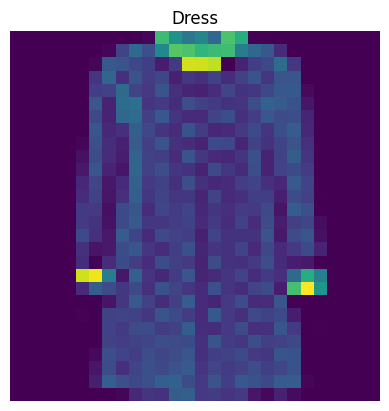

In [19]:
img = train_features[16]

plt.imshow(img.squeeze())
plt.axis("off")
plt.title(class_names[train_label[16].item()])

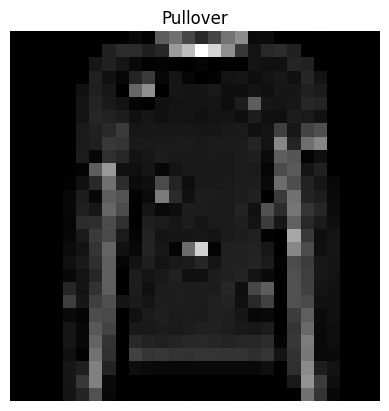

In [20]:
for i in range(1, len(train_features)):
    rand_idx = torch.randint(0, len(train_features), size = (1,)).item()
    img, label = train_features[rand_idx], train_label[rand_idx]
    plt.imshow(img.squeeze(), cmap="grey")
    plt.title(class_names[label])
    plt.axis(False)

In [21]:
train_label.unique().squeeze()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [22]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [55]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, input_features: int = None, output_features: int = None, hidden_units: int = 10):
        super(FashionMNISTModel, self).__init__()
        
        self.network = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(
                in_features = input_features, out_features = hidden_units
            ),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(
                in_features = hidden_units, out_features = output_features
            )
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [56]:
train_features.shape

torch.Size([32, 1, 28, 28])

In [57]:
torch.manual_seed(42)

In [58]:
model = FashionMNISTModel(input_features = 784, output_features = len(class_names), hidden_units = 32).to(device)
# model.to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [59]:
from timeit import default_timer as timer

def calculate_training_time(start: float, end: float, device: torch.device = "cpu"):
    time_taken = end - start
    print(f"Time Taken : {time_taken:.3f}, on Device: {device}")
    return

In [60]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
accuracy_fn = MulticlassAccuracy(num_classes = 10).to(device)

In [61]:
epochs = 30
start = timer()

for epoch in tqdm(range(epochs)):
    running_loss = 0.0
    running_acc = 0.0
    model.train()

    for idx, (image, target) in enumerate(train_loader):
        image, target = image.to(device), target.to(device)
        target_pred_logits = model(image)
        # target_pred = torch.argmax(target_pred_logits, dim = 1)
        # train_accuracy = accuracy_fn(target, target_pred)

        loss = loss_fn(target_pred_logits, target)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        target_pred = torch.argmax(target_pred_logits, dim = 1)
        train_accuracy = accuracy_fn(target, target_pred)
        running_loss += loss
        running_acc += train_accuracy

    avg_loss = running_loss / len(train_loader)
    avg_acc = running_acc / len(train_loader)

    # if idx % (0.1 * len(train_loader)) == 0:
    if epoch % (0.1 * epochs) == 0:
        print(f"Traning Loss: {avg_loss} | Accuracy: {avg_acc}")

end = timer()
calculate_training_time(start, end, device)

  3%|█▍                                          | 1/30 [00:06<03:10,  6.58s/it]

Traning Loss: 0.5860593318939209 | Accuracy: 0.7780675292015076


 13%|█████▊                                      | 4/30 [00:26<02:49,  6.51s/it]

Traning Loss: 0.37290653586387634 | Accuracy: 0.8583554625511169


 23%|██████████▎                                 | 7/30 [00:45<02:30,  6.54s/it]

...

Traning Loss: 0.27838221192359924 | Accuracy: 0.8899269104003906


 93%|████████████████████████████████████████▏  | 28/30 [03:06<00:13,  6.70s/it]

Traning Loss: 0.27373164892196655 | Accuracy: 0.8935164213180542


100%|███████████████████████████████████████████| 30/30 [03:19<00:00,  6.65s/it]

Time Taken : 199.511, on Device: mps


In [73]:
torch.manual_seed(42)

model.eval()
test_features, test_label = next(iter(test_loader))

single_img = test_features[0].unsqueeze(dim = 1).to(device)

with torch.inference_mode():
    target_logits = model(single_img)
    target_pred = torch.argmax(target_logits, dim = 1)


# class_names[target_pred], class_names[test_label[0]]

plt.imshow(test_features[0])
pl.

('Dress', 'Dress')